# 01 — Data Acquisition
**Project**: YOLOv11s Person Detection  
**Tujuan**: Mengambil 3000 gambar class `person` dari COCO 2017 menggunakan `fiftyone`

---

## 1.1 Install Dependencies

In [1]:
# !pip install fiftyone ultralytics torch torchvision opencv-python matplotlib seaborn pandas numpy Pillow tqdm

## 1.2 Import Libraries

In [2]:
import fiftyone as fo
import fiftyone.zoo as foz
import os
import json
import shutil
from pathlib import Path

print(f'FiftyOne version : {fo.__version__}')

C:\Users\naufa\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FiftyOne version : 1.14.0


## 1.3 Konfigurasi Path

In [3]:
# ── Direktori output ──────────────────────────────────────────────────────────
RAW_DIR        = Path('data/raw')
RAW_IMAGES_DIR = RAW_DIR / 'images'
RAW_ANNOT_DIR  = RAW_DIR / 'annotations'

RAW_DIR.mkdir(parents=True, exist_ok=True)
RAW_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
RAW_ANNOT_DIR.mkdir(parents=True, exist_ok=True)

# ── Parameter download ────────────────────────────────────────────────────────
TARGET_CLASS   = 'person'
MAX_SAMPLES    = 3000
COCO_SPLIT     = 'train'       # Sumber: train split COCO 2017 (memiliki anotasi lengkap)
RANDOM_SEED    = 42

print('Konfigurasi:')
print(f'  Class target  : {TARGET_CLASS}')
print(f'  Jumlah gambar : {MAX_SAMPLES}')
print(f'  COCO split    : {COCO_SPLIT}')
print(f'  Random seed   : {RANDOM_SEED}')
print(f'  Output dir    : {RAW_DIR.resolve()}')

Konfigurasi:
  Class target  : person
  Jumlah gambar : 3000
  COCO split    : train
  Random seed   : 42
  Output dir    : C:\NaufalFirdaus\CODES\AI\person-tracker-yolov11\files\data\raw


## 1.4 Download COCO 2017 (Subset: Person)

FiftyOne akan otomatis:
- Download gambar + anotasi dari COCO 2017
- Filter hanya class `person`
- Ambil maksimal `MAX_SAMPLES` gambar

> **Catatan**: Proses download memerlukan koneksi internet. Estimasi ~1–3 GB data.

In [ ]:
dataset = foz.load_zoo_dataset(
    'coco-2017',
    split=COCO_SPLIT,
    label_types=['detections'],
    classes=[TARGET_CLASS], #person
    max_samples=MAX_SAMPLES,
    seed=RANDOM_SEED,
    shuffle=True,
    dataset_name=f'coco2017_{TARGET_CLASS}_{MAX_SAMPLES}',
    overwrite=False
)

print(f'\nDataset berhasil di-load!')
print(f'Jumlah sampel : {len(dataset)}')
print(f'Info dataset  :')
print(dataset)

Found annotations at 'C:\Users\naufa\fiftyone\coco-2017\raw\instances_train2017.json'
Sufficient images already downloaded
Existing download of split 'train' is sufficient
Loading existing dataset 'coco2017_person_3000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use

Dataset berhasil di-load!
Jumlah sampel : 3000
Info dataset  :
Name:        coco2017_person_3000
Media type:  image
Num samples: 3000
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.l

## 1.5 Filter: Hanya Gambar dengan Anotasi `person`

Pastikan setiap gambar benar-benar memiliki minimal 1 bounding box `person`.

In [ ]:
from fiftyone import ViewField as F

# Filter: hanya sample yang memiliki deteksi person
view = dataset.filter_labels(
    'ground_truth',
    F('label') == 'person'
).match(
    F('ground_truth.detections').length() > 0
)

print(f'Sebelum filter : {len(dataset)} gambar')
print(f'Setelah filter : {len(view)} gambar (hanya yang punya anotasi person)')

Sebelum filter : 3000 gambar
Setelah filter : 3000 gambar (hanya yang punya anotasi person)


## 1.6 Export ke COCO Format (JSON + Gambar)

Simpan dataset ke direktori lokal dalam format COCO untuk diproses di notebook berikutnya.

In [6]:
import shutil
from tqdm import tqdm

# Export dataset ke COCO format
view.export(
    export_dir=str(RAW_DIR),
    dataset_type=fo.types.COCODetectionDataset,
    label_field='ground_truth',
    classes=[TARGET_CLASS],
    overwrite=True
)

print('Export selesai!')
print(f'Gambar disimpan di : {RAW_IMAGES_DIR}')
print(f'Anotasi disimpan di: {RAW_ANNOT_DIR}')

 100% |███████████████| 3000/3000 [6.7s elapsed, 0s remaining, 447.5 samples/s]       
Export selesai!
Gambar disimpan di : data\raw\images
Anotasi disimpan di: data\raw\annotations


## 1.7 Verifikasi Hasil Download

In [7]:
import json
from pathlib import Path

# Hitung jumlah file gambar
image_files = list(RAW_IMAGES_DIR.glob('*.jpg')) + \
              list(RAW_IMAGES_DIR.glob('*.jpeg')) + \
              list(RAW_IMAGES_DIR.glob('*.png'))

print(f'Jumlah file gambar : {len(image_files)}')

# Baca file anotasi JSON
annot_file = RAW_ANNOT_DIR / 'labels.json'
if not annot_file.exists():
    # cari file json di raw dir
    json_files = list(RAW_DIR.rglob('*.json'))
    if json_files:
        annot_file = json_files[0]

with open(annot_file) as f:
    coco_data = json.load(f)

n_images      = len(coco_data.get('images', []))
n_annotations = len(coco_data.get('annotations', []))
n_categories  = len(coco_data.get('categories', []))

print(f'\nIsi file anotasi ({annot_file.name}):')
print(f'  Jumlah gambar     : {n_images}')
print(f'  Jumlah anotasi    : {n_annotations}')
print(f'  Jumlah kategori   : {n_categories}')
print(f'  Kategori          : {[c["name"] for c in coco_data["categories"]]}')
print(f'\nRata-rata bbox/gambar: {n_annotations / n_images:.2f}')

# Simpan path file anotasi untuk notebook selanjutnya
import json
config = {
    'annot_file'    : str(annot_file),
    'raw_images_dir': str(RAW_IMAGES_DIR),
    'total_images'  : n_images,
    'total_annot'   : n_annotations,
    'target_class'  : TARGET_CLASS,
    'random_seed'   : RANDOM_SEED
}
with open('data/acquisition_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('\nKonfigurasi disimpan ke data/acquisition_config.json')

Jumlah file gambar : 0

Isi file anotasi (labels.json):
  Jumlah gambar     : 3000
  Jumlah anotasi    : 12565
  Jumlah kategori   : 1
  Kategori          : ['person']

Rata-rata bbox/gambar: 4.19

Konfigurasi disimpan ke data/acquisition_config.json


## 1.8 Preview Sampel Gambar

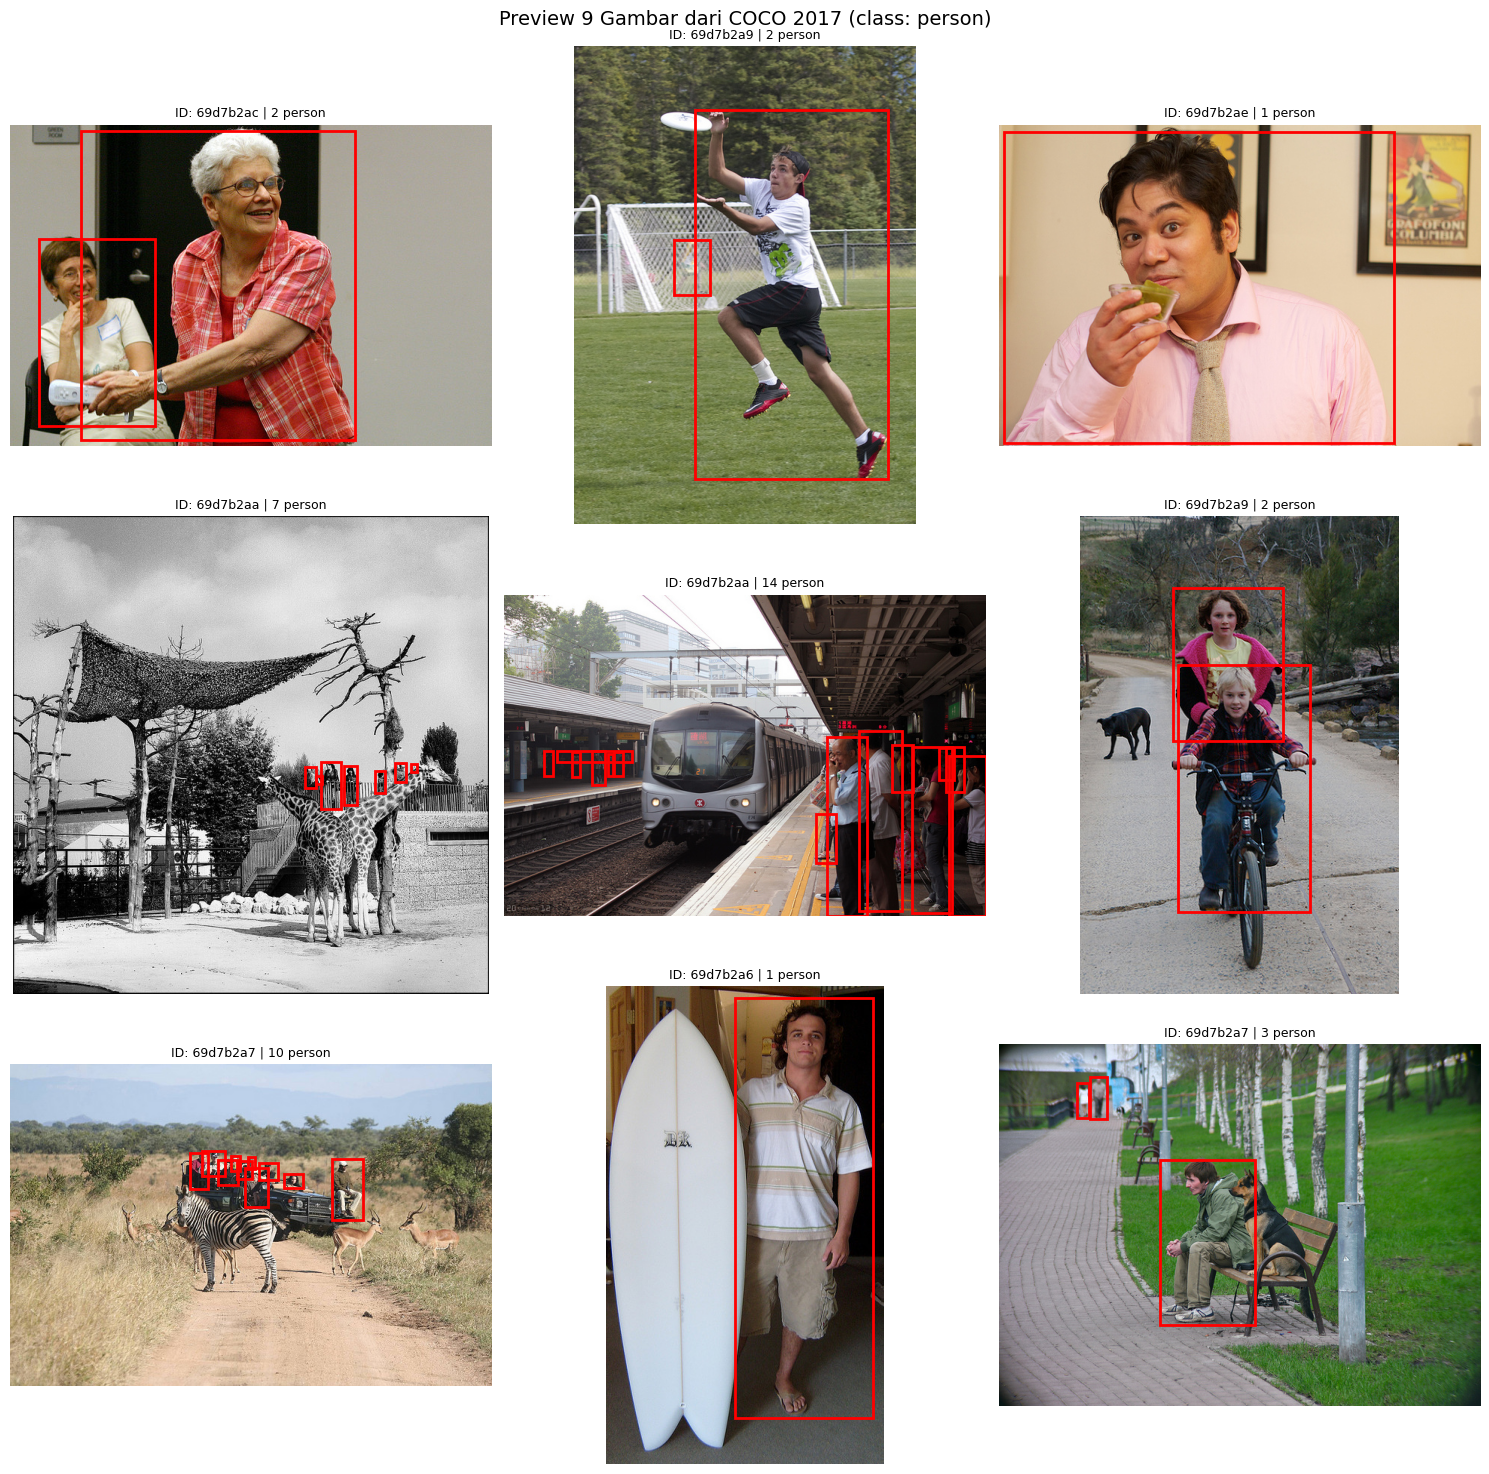

Preview disimpan ke data/preview_samples.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

random.seed(RANDOM_SEED)

# Ambil 9 sampel langsung dari fiftyone view (pakai filepath asli)
sample_list = list(view.take(9, seed=RANDOM_SEED))

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Preview 9 Gambar dari COCO 2017 (class: person)', fontsize=14)

for ax, sample in zip(axes.flat, sample_list):
    img_path = sample.filepath          # path asli dari fiftyone cache
    if os.path.exists(img_path):
        img     = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        ax.imshow(img)

        detections = sample.ground_truth.detections if sample.ground_truth else []
        for det in detections:
            # fiftyone bbox = [x, y, w, h] dalam format relatif (0–1)
            x, y, w, h = det.bounding_box
            rect = patches.Rectangle(
                (x * img_w, y * img_h), w * img_w, h * img_h,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
        ax.set_title(f'ID: {sample.id[:8]} | {len(detections)} person', fontsize=9)
    else:
        ax.set_title('File tidak ditemukan', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('data/preview_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Preview disimpan ke data/preview_samples.png')

---
## ✅ Ringkasan Notebook 01

| Item | Hasil |
|------|-------|
| Dataset | COCO 2017 (train split) |
| Class | `person` saja |
| Jumlah gambar | ~3000 |
| Format output | COCO JSON + gambar JPG |
| Config tersimpan | `data/acquisition_config.json` |

**Langkah selanjutnya** → `02_preprocessing_eda.ipynb`